# Погода и спрос на такси в Нью-Йорке (2024)

**Вопрос:** есть ли в Нью-Йорке связь между плохой погодой (дождь, снег, ветер) и ростом числа поездок на такси?

**Данные:**
- Поездки: официальные архивы NYC TLC (Taxi & Limousine Commission) — parquet-файлы `yellow` (желтые такси), `green` (зеленые такси) и `fhvhv` (Uber/Lyft/Via — High-Volume For-Hire Vehicles) за 2024 год.
- Погода: NOAA GHCN Daily Summaries, метеостанция **Central Park, NY (USW00094728)** — осадки, снег, температура, ветер по дням за 2024 год.

**Важное уточнение терминов.** В NYC официально «taxi» — это желтые (Манхэттен) и зеленые (окраины) такси, которые можно поймать на улице. Uber/Lyft/Via юридически называются «for-hire vehicles» (FHV), но именно их сегодня чаще всего «вызывают» через приложение. Поэтому ниже сравниваются оба вида — картина для них разная.

**Период:** 1 января – 31 декабря 2024 (366 дней, високосный год).


In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option("display.width", 120)
con = duckdb.connect()
TAXI_DIR = "/sessions/ecstatic-upbeat-fermat/mnt/NYC/TLC_Trip_Data"
print("DuckDB version:", duckdb.__version__)

DuckDB version: 1.5.5


## 1. Агрегация поездок такси по дням (DuckDB + parquet)

In [2]:
yellow = con.execute(f"""
    SELECT CAST(tpep_pickup_datetime AS DATE) AS trip_date, COUNT(*) AS yellow_trips
    FROM read_parquet('{TAXI_DIR}/yellow/yellow_tripdata_2024-*.parquet')
    WHERE tpep_pickup_datetime >= TIMESTAMP '2024-01-01'
      AND tpep_pickup_datetime <  TIMESTAMP '2025-01-01'
    GROUP BY trip_date ORDER BY trip_date
""").fetchdf()
print(f"Желтые такси: {len(yellow)} дней, всего поездок: {yellow['yellow_trips'].sum():,}")
yellow.head()

Желтые такси: 366 дней, всего поездок: 41,169,664
   trip_date  yellow_trips
0 2024-01-01         81013
1 2024-01-02         75519
2 2024-01-03         82427
3 2024-01-04        102901
4 2024-01-05        103178


In [3]:
green = con.execute(f"""
    SELECT CAST(lpep_pickup_datetime AS DATE) AS trip_date, COUNT(*) AS green_trips
    FROM read_parquet('{TAXI_DIR}/green/green_tripdata_2024-*.parquet')
    WHERE lpep_pickup_datetime >= TIMESTAMP '2024-01-01'
      AND lpep_pickup_datetime <  TIMESTAMP '2025-01-01'
    GROUP BY trip_date ORDER BY trip_date
""").fetchdf()
print(f"Зеленые такси: {len(green)} дней, всего поездок: {green['green_trips'].sum():,}")
green.head()

Зеленые такси: 366 дней, всего поездок: 660,198
   trip_date  green_trips
0 2024-01-01         1189
1 2024-01-02         1668
2 2024-01-03         1790
3 2024-01-04         2101
4 2024-01-05         2119


In [4]:
fhvhv = con.execute(f"""
    SELECT CAST(pickup_datetime AS DATE) AS trip_date, COUNT(*) AS fhvhv_trips
    FROM read_parquet('{TAXI_DIR}/fhvhv/fhvhv_tripdata_2024-*.parquet')
    WHERE pickup_datetime >= TIMESTAMP '2024-01-01'
      AND pickup_datetime <  TIMESTAMP '2025-01-01'
    GROUP BY trip_date ORDER BY trip_date
""").fetchdf()
print(f"Uber/Lyft/Via (FHVHV): {len(fhvhv)} дней, всего поездок: {fhvhv['fhvhv_trips'].sum():,}")
fhvhv.head()

Uber/Lyft/Via (FHVHV): 366 дней, всего поездок: 239,470,448
   trip_date  fhvhv_trips
0 2024-01-01       638406
1 2024-01-02       478254
2 2024-01-03       498332
3 2024-01-04       572632
4 2024-01-05       656654


## 2. Погода по дням (NOAA, Central Park)

Данные загружены из NOAA GHCN Daily Summaries (`https://www.ncei.noaa.gov/access/services/data/v1`, dataset `daily-summaries`, станция `USW00094728`) и сохранены в `weather_daily_2024.csv`. Единицы: осадки/снег — мм, температура — °C, ветер — м/с.

In [5]:
weather = pd.read_csv("weather_daily_2024.csv", parse_dates=["date"])
print(f"Погода: {len(weather)} дней ({weather['date'].min().date()} .. {weather['date'].max().date()})")
weather.describe().round(2)

Погода: 366 дней (2024-01-01 .. 2024-12-31)
                                date  prcp_mm  snow_mm  snwd_mm  tmax_c  tmin_c  awnd_ms  wsf5_ms
count                            366   366.00   366.00   366.00  366.00  366.00   362.00   365.00
mean   2024-07-01 12:00:00.000000256     3.22     0.71     1.64   18.32   10.54     2.19    10.69
min              2024-01-01 00:00:00     0.00     0.00     0.00   -6.00  -10.50     0.40     4.50
25%              2024-04-01 06:00:00     0.00     0.00     0.00   10.60    4.40     1.40     8.50
50%              2024-07-01 12:00:00     0.00     0.00     0.00   18.90   10.00     2.10     9.80
75%              2024-09-30 18:00:00     1.30     0.00     0.00   26.70   17.80     2.80    12.50
max              2024-12-31 00:00:00    93.00    81.00    50.00   35.00   26.10     6.30    26.40
std                              NaN     9.39     5.98     7.41    9.51    8.40     1.01     3.40


## 3. Объединение данных

In [6]:
df = yellow.merge(green, on="trip_date").merge(fhvhv, on="trip_date")
df = df.merge(weather, left_on="trip_date", right_on="date").drop(columns=["date"])

df["taxi_trips"] = df["yellow_trips"] + df["green_trips"]   # официальные такси (желтые+зеленые)
df["weekday"] = df["trip_date"].dt.weekday                   # 0=Пн ... 6=Вс
df["is_weekend"] = df["weekday"].isin([5, 6])
df["month"] = df["trip_date"].dt.month

print(df.shape)
df[["trip_date","taxi_trips","fhvhv_trips","prcp_mm","snow_mm","tmax_c","awnd_ms"]].head()

(366, 15)
   trip_date  taxi_trips  fhvhv_trips  prcp_mm  snow_mm  tmax_c  awnd_ms
0 2024-01-01       82202       638406      0.8      0.0     8.3      1.5
1 2024-01-02       77187       478254      0.0      0.0     5.6      1.8
2 2024-01-03       84217       498332      0.0      0.0     6.1      2.2
3 2024-01-04      105002       572632      0.0      0.0     7.2      3.4
4 2024-01-05      105297       656654      0.0      0.0     2.8      3.2


## 4. Корреляции

Спрос на такси сильно зависит от дня недели (будни/выходные) — это главный "конфаундер". Поэтому считаем не только сырую корреляцию Пирсона, но и корреляцию **после вычитания среднего по дню недели** (`anomaly = trips - mean(trips | weekday)`), что изолирует эффект погоды от недельной сезонности.

Так как `scipy` недоступен в песочнице (нет сетевого доступа к недостающим пакетам), значимость (p-value) считается **перестановочным тестом** (permutation test, 20 000 перестановок) — это не менее строгий непараметрический метод.

In [7]:
def pearson(x, y):
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    mask = ~(np.isnan(x) | np.isnan(y))
    return np.corrcoef(x[mask], y[mask])[0, 1], mask.sum()

def perm_pvalue(x, y, n=20000, seed=42):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    r_obs = np.corrcoef(x, y)[0, 1]
    hits = 0
    for _ in range(n):
        r = np.corrcoef(x, rng.permutation(y))[0, 1]
        if abs(r) >= abs(r_obs):
            hits += 1
    return r_obs, hits / n

weather_cols = ["prcp_mm", "snow_mm", "tmax_c", "tmin_c", "awnd_ms", "wsf5_ms"]

print("=== Сырая корреляция Пирсона: поездки vs погода ===")
print(f"{'':10s} {'такси (ж+з)':>14s} {'Uber/Lyft/Via':>16s}")
for col in weather_cols:
    r1, _ = pearson(df["taxi_trips"], df[col])
    r2, _ = pearson(df["fhvhv_trips"], df[col])
    print(f"{col:10s} {r1:+14.3f} {r2:+16.3f}")

=== Сырая корреляция Пирсона: поездки vs погода ===
              такси (ж+з)    Uber/Lyft/Via
prcp_mm            +0.045           +0.213
snow_mm            -0.123           -0.001
tmax_c             -0.024           -0.187
tmin_c             -0.027           -0.174
awnd_ms            +0.160           +0.250
wsf5_ms            +0.152           +0.266


In [8]:
df["taxi_anom"]  = df["taxi_trips"]  - df.groupby("weekday")["taxi_trips"].transform("mean")
df["fhvhv_anom"] = df["fhvhv_trips"] - df.groupby("weekday")["fhvhv_trips"].transform("mean")

print("=== Корреляция ПОСЛЕ поправки на день недели (anomaly), с perm p-value ===\n")
for label, col in [("Такси (желтые+зеленые)", "taxi_anom"), ("Uber/Lyft/Via (FHVHV)", "fhvhv_anom")]:
    print(f"-- {label} --")
    for wcol in weather_cols:
        r, p = perm_pvalue(df[col], df[wcol])
        star = "  <-- значимо (p<0.05)" if p < 0.05 else ""
        print(f"   {wcol:10s}: r={r:+.3f}   perm p={p:.4f}{star}")
    print()

=== Корреляция ПОСЛЕ поправки на день недели (anomaly), с perm p-value ===

-- Такси (желтые+зеленые) --
   prcp_mm   : r=+0.007   perm p=0.9028
   snow_mm   : r=-0.155   perm p=0.0057  <-- значимо (p<0.05)
   tmax_c    : r=-0.023   perm p=0.6646
   tmin_c    : r=-0.037   perm p=0.4784
   awnd_ms   : r=+0.153   perm p=0.0031  <-- значимо (p<0.05)
   wsf5_ms   : r=+0.134   perm p=0.0097  <-- значимо (p<0.05)

-- Uber/Lyft/Via (FHVHV) --
   prcp_mm   : r=+0.266   perm p=0.0000  <-- значимо (p<0.05)
   snow_mm   : r=-0.027   perm p=0.5773
   tmax_c    : r=-0.285   perm p=0.0000  <-- значимо (p<0.05)
   tmin_c    : r=-0.272   perm p=0.0000  <-- значимо (p<0.05)
   awnd_ms   : r=+0.341   perm p=0.0000  <-- значимо (p<0.05)
   wsf5_ms   : r=+0.350   perm p=0.0000  <-- значимо (p<0.05)



## 5. Дождливые / снежные дни vs обычные

Сравниваем среднюю (уже скорректированную на день недели) аномалию числа поездок в дождливые дни (осадки ≥ 1 мм), в дни с сильным дождем (≥ 10 мм) и в снежные дни — против всех остальных.

In [9]:
def group_perm_test(anom, group_mask, n=20000, seed=1):
    rng = np.random.default_rng(seed)
    anom = np.asarray(anom, dtype=float)
    group_mask = np.asarray(group_mask, dtype=bool)
    obs_diff = anom[group_mask].mean() - anom[~group_mask].mean()
    diffs = np.empty(n)
    for i in range(n):
        perm = rng.permutation(group_mask)
        diffs[i] = anom[perm].mean() - anom[~perm].mean()
    p = (np.abs(diffs) >= np.abs(obs_diff)).mean()
    return obs_diff, p

rain_mask = df["prcp_mm"] >= 1.0
heavy_rain_mask = df["prcp_mm"] >= 10.0
snow_mask = df["snow_mm"] > 0.0

print(f"Дождливых дней (>=1мм):  {rain_mask.sum()} / {len(df)}")
print(f"Дней с сильным дождем (>=10мм): {heavy_rain_mask.sum()} / {len(df)}")
print(f"Снежных дней (>0мм снега): {snow_mask.sum()} / {len(df)}\n")

for label, col in [("Такси (желтые+зеленые)", "taxi_anom"), ("Uber/Lyft/Via (FHVHV)", "fhvhv_anom")]:
    print(f"--- {label} ---")
    d, p = group_perm_test(df[col], rain_mask)
    print(f"  Дождь(>=1мм) vs сухо:        {d:+8.0f} поездок/день   p={p:.4f}")
    d, p = group_perm_test(df[col], heavy_rain_mask)
    print(f"  Сильный дождь(>=10мм) vs остальное: {d:+8.0f} поездок/день   p={p:.4f}")
    d, p = group_perm_test(df[col], snow_mask)
    print(f"  Снег(>0мм) vs без снега:     {d:+8.0f} поездок/день   p={p:.4f}")
    print()

Дождливых дней (>=1мм):  105 / 366
Дней с сильным дождем (>=10мм): 32 / 366
Снежных дней (>0мм снега): 8 / 366

--- Такси (желтые+зеленые) ---
  Дождь(>=1мм) vs сухо:           -2752 поездок/день   p=0.1501
  Сильный дождь(>=10мм) vs остальное:     -615 поездок/день   p=0.8426
  Снег(>0мм) vs без снега:       -20324 поездок/день   p=0.0010

--- Uber/Lyft/Via (FHVHV) ---
  Дождь(>=1мм) vs сухо:          +17917 поездок/день   p=0.0007
  Сильный дождь(>=10мм) vs остальное:   +40018 поездок/день   p=0.0000
  Снег(>0мм) vs без снега:        -2581 поездок/день   p=0.8767



## 6. Множественная регрессия (стандартизованные коэффициенты)

Осадки, снег, температура и ветер часто коррелируют друг с другом (например, сильный ветер часто сопутствует дождю). Множественная регрессия показывает вклад **каждого** фактора при фиксированных остальных.

In [10]:
from numpy.linalg import lstsq

for label, col in [("Такси (желтые+зеленые)", "taxi_anom"), ("Uber/Lyft/Via (FHVHV)", "fhvhv_anom")]:
    sub = df.dropna(subset=["awnd_ms"]).copy()
    X = sub[["prcp_mm", "snow_mm", "tmax_c", "awnd_ms"]].values.astype(float)
    Xz = (X - X.mean(axis=0)) / X.std(axis=0)
    y = sub[col].values.astype(float)
    yz = (y - y.mean()) / y.std()
    Xd = np.column_stack([np.ones(len(Xz)), Xz])
    coef, *_ = lstsq(Xd, yz, rcond=None)
    pred = Xd @ coef
    r2 = 1 - ((yz - pred) ** 2).sum() / ((yz - yz.mean()) ** 2).sum()
    print(f"--- {label}: R² = {r2:.3f} ---")
    for name, c in zip(["intercept", "prcp_mm", "snow_mm", "tmax_c", "awnd_ms"], coef):
        print(f"    {name:10s} beta = {c:+.3f}")
    print()

--- Такси (желтые+зеленые): R² = 0.060 ---
    intercept  beta = -0.000
    prcp_mm    beta = +0.000
    snow_mm    beta = -0.182
    tmax_c     beta = +0.063
    awnd_ms    beta = +0.222

--- Uber/Lyft/Via (FHVHV): R² = 0.200 ---
    intercept  beta = +0.000
    prcp_mm    beta = +0.246
    snow_mm    beta = -0.122
    tmax_c     beta = -0.168
    awnd_ms    beta = +0.241



## 7. Графики

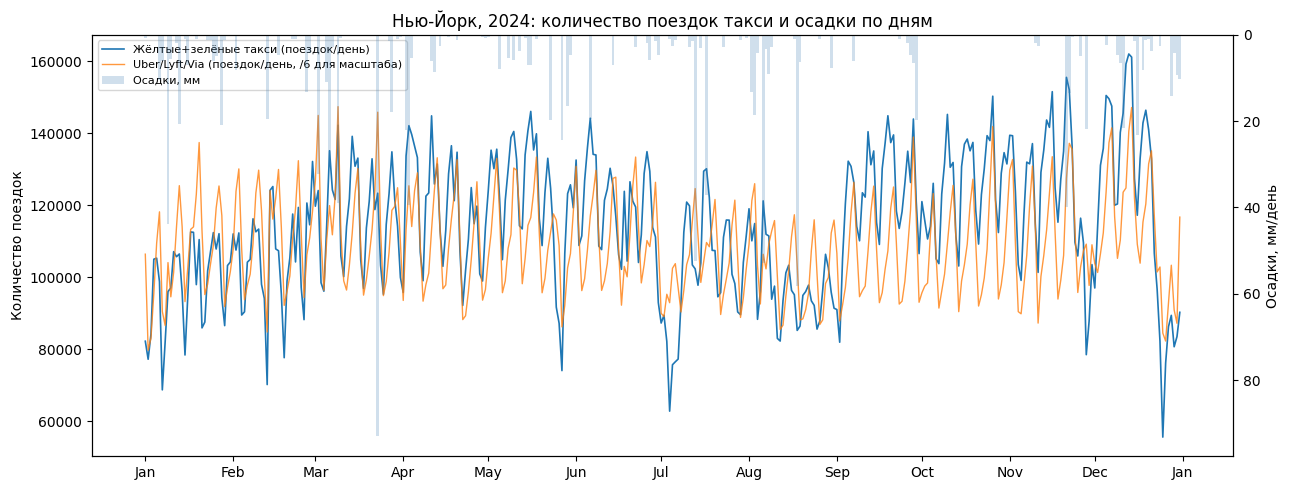

In [11]:
fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(df["trip_date"], df["taxi_trips"], color="#1f77b4", lw=1.2, label="Желтые+зеленые такси (поездок/день)")
ax1.plot(df["trip_date"], df["fhvhv_trips"] / 6, color="#ff7f0e", lw=1.0, alpha=0.8,
         label="Uber/Lyft/Via (поездок/день, /6 для масштаба)")
ax1.set_ylabel("Количество поездок")
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax2 = ax1.twinx()
ax2.bar(df["trip_date"], df["prcp_mm"], color="steelblue", alpha=0.25, width=1.0, label="Осадки, мм")
ax2.set_ylabel("Осадки, мм/день")
ax2.invert_yaxis()
l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, loc="upper left", fontsize=8)
ax1.set_title("Нью-Йорк, 2024: количество поездок такси и осадки по дням")
plt.tight_layout()
plt.show()

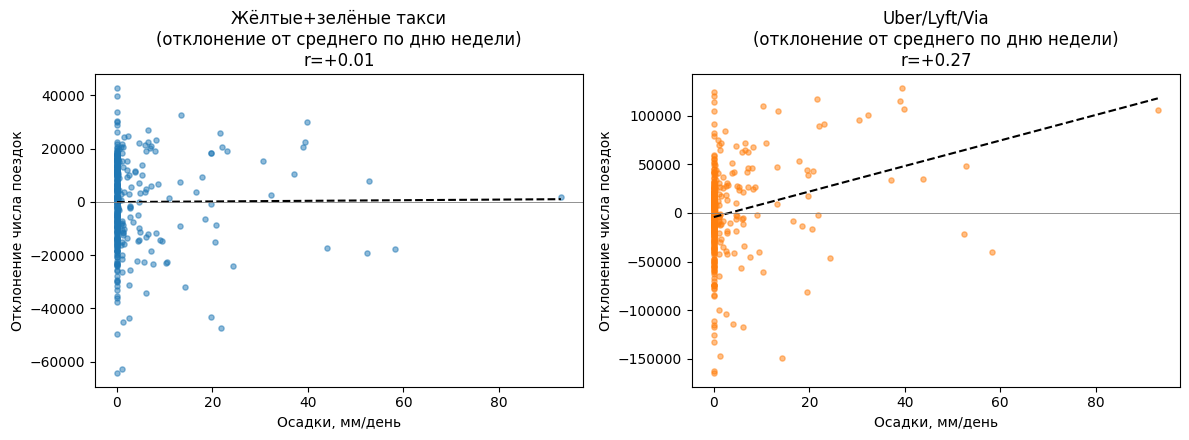

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col, title, color in [
    (axes[0], "taxi_anom", "Желтые+зеленые такси\n(отклонение от среднего по дню недели)", "#1f77b4"),
    (axes[1], "fhvhv_anom", "Uber/Lyft/Via\n(отклонение от среднего по дню недели)", "#ff7f0e"),
]:
    x = df["prcp_mm"].values
    y = df[col].values
    ax.scatter(x, y, s=14, alpha=0.5, color=color)
    b, a = np.polyfit(x, y, 1)
    xs = np.linspace(0, x.max(), 50)
    ax.plot(xs, a + b * xs, color="black", lw=1.5, ls="--")
    r = np.corrcoef(x, y)[0, 1]
    ax.set_xlabel("Осадки, мм/день")
    ax.set_ylabel("Отклонение числа поездок")
    ax.set_title(f"{title}\nr={r:+.2f}")
    ax.axhline(0, color="gray", lw=0.6)
plt.tight_layout()
plt.show()

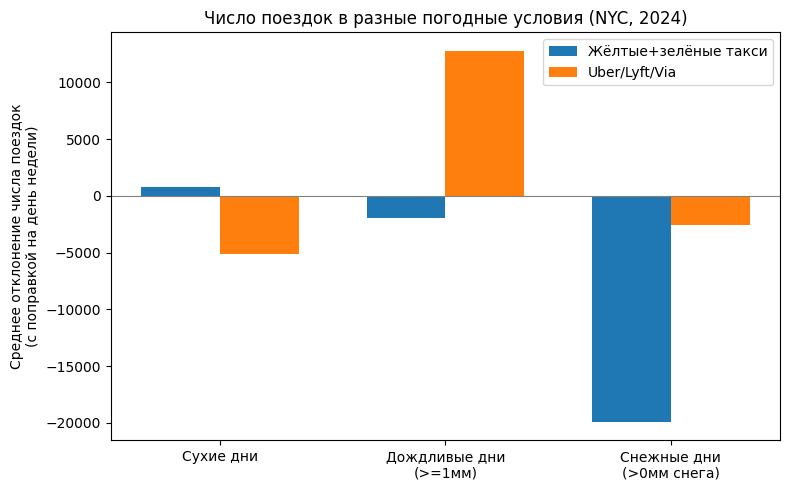

In [13]:
rain_mask = df["prcp_mm"] >= 1.0
snow_mask = df["snow_mm"] > 0.0
labels = ["Сухие дни", "Дождливые дни\n(>=1мм)", "Снежные дни\n(>0мм снега)"]
taxi_vals = [df.loc[~rain_mask, "taxi_anom"].mean(), df.loc[rain_mask, "taxi_anom"].mean(), df.loc[snow_mask, "taxi_anom"].mean()]
fhvhv_vals = [df.loc[~rain_mask, "fhvhv_anom"].mean(), df.loc[rain_mask, "fhvhv_anom"].mean(), df.loc[snow_mask, "fhvhv_anom"].mean()]

x = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, taxi_vals, w, label="Желтые+зеленые такси", color="#1f77b4")
ax.bar(x + w/2, fhvhv_vals, w, label="Uber/Lyft/Via", color="#ff7f0e")
ax.axhline(0, color="gray", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Среднее отклонение числа поездок\n(с поправкой на день недели)")
ax.set_title("Число поездок в разные погодные условия (NYC, 2024)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Выводы

**Короткий ответ: зависит от вида такси.**

1. **Классические желтые/зеленые такси (street-hail).** Статистически значимой связи с дождем не обнаружено (r ≈ 0, p ≈ 0.9). А вот в снежные дни число поездок заметно **падает** (в среднем −15…20 тыс. поездок/день с поправкой на день недели, p ≈ 0.001) — вероятно, из-за снижения общей мобильности, меньшего числа туристов и того, что поймать машину на улице в снегопад физически сложнее.

2. **Uber/Lyft/Via (FHVHV).** Здесь связь с дождем четкая и статистически значимая: в дождливые дни поездок в среднем на **~18 тыс. больше** (p < 0.001), а в дни с сильным дождем (≥10 мм) — на **~40 тыс. больше** (p < 0.0001). Множественная регрессия подтверждает эффект осадков (β ≈ +0.25) даже с поправкой на температуру и ветер. Со снегом устойчивой связи не найдено (возможно, из-за малого числа снежных дней в выборке — всего 8 из 366).

3. **Интерпретация.** Правило «в плохую погоду больше вызывают такси» подтверждается для приложений (Uber/Lyft) — заказать машину из дома/офиса в дождь проще, чем ловить ее на улице, а спрос на поездки вместо пешей ходьбы в дождь растет. Для классических уличных такси эффект либо отсутствует, либо обратный — вероятно потому, что дождь одновременно снижает и предложение (труднее ехать/парковаться), и число людей, готовых стоять и ловить машину на улице.

**Оговорки:** это один календарный год данных по одной метеостанции (Central Park); связь корреляционная, не причинно-следственная; ветер тоже показывает слабую положительную связь с числом поездок, но, вероятно, это частично отражает общую "непогоду" (штормовые дни сочетают дождь и ветер), а не независимый эффект.
